In [1]:
import torch
from S3BIR_DINO.dinov3_model import S3birDinov3

ckpt_path = "S3BIR_DINO/skDinoV3_sketchy.ckpt" #"s3bir_dinov2_flickr.ckpt"
checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
state_dict = checkpoint.get("state_dict", checkpoint)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = S3birDinov3().to(device)
model.load_state_dict(state_dict)
model.eval()

print("Model loaded and set to eval mode.")

Model loaded and set to eval mode.


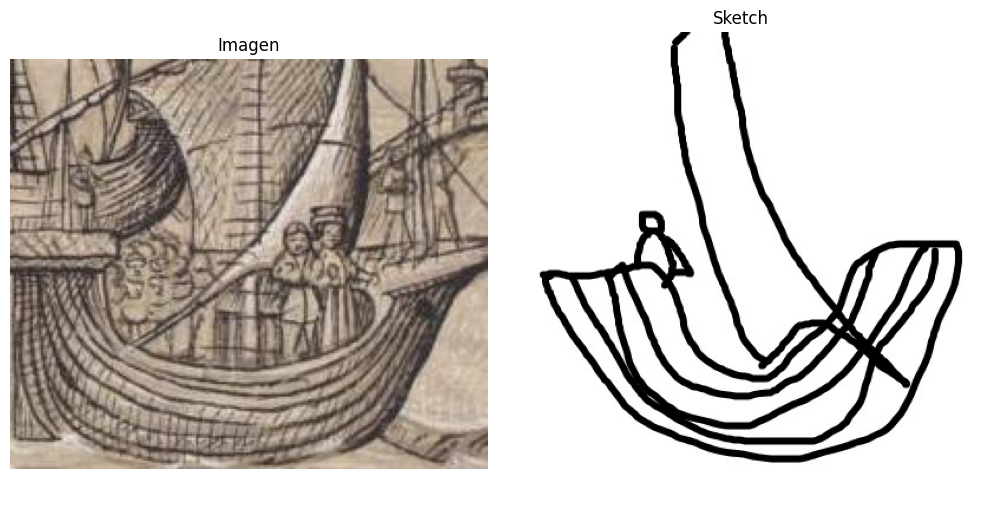

In [12]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

img = Image.open("DocExplore/DocExplore_queries_web/bateau/1348.jpg").convert("RGB")
sketch = Image.open("DocExplore/Sketches/sketch_1_DocExplore_bateau_1349_4x_1349.jpeg").convert("RGB")

# Visualización lado a lado
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img)
axs[0].set_title("Imagen")
axs[0].axis("off")

axs[1].imshow(sketch)
axs[1].set_title("Sketch")
axs[1].axis("off")

plt.tight_layout()
plt.show()

# Tensores (igual que antes)
img_tensor = transform(img).unsqueeze(0).to(device)
sketch_tensor = transform(sketch).unsqueeze(0).to(device)

In [9]:
import torch

with torch.no_grad():
    # The model expects a dtype flag to distinguish modalities
    img_embedding = model(img_tensor, dtype="image")         # shape: [1, D]
    sketch_embedding = model(sketch_tensor, dtype="sketch")  # shape: [1, D]

print("Image embedding shape:", tuple(img_embedding.shape))
print("Sketch embedding shape:", tuple(sketch_embedding.shape))

Image embedding shape: (1, 768)
Sketch embedding shape: (1, 768)


In [10]:
import torch.nn.functional as F

cos_sim = F.cosine_similarity(img_embedding, sketch_embedding)
print("Cosine similarity:", cos_sim.item())

Cosine similarity: 0.43694746494293213
